# NewForge emulator

In [2]:
from NewForge import BoostPredictor, test_predict
import numpy as np
import matplotlib.pyplot as plt
from pkg_resources import resource_stream

# set matplotlib style
plt.style.use(resource_stream('nDGPemu','cache/my_style.ini').name)

## Load the emulator

In [3]:
model = BoostPredictor()

Loading model and related data


In [4]:
test_predict(model)

All tests passed successfully.


## Estimate boost factor for example parameters and plot results

In [5]:
# Define parameters
cosmo_params = {'Om':0.32,
                'sigma8':0.8}

fR0 = 1e-5
z = 1

# Get boost for training k values
Bk = model.predict(fR0,z,cosmo_params)
k_vals = model.k_vals

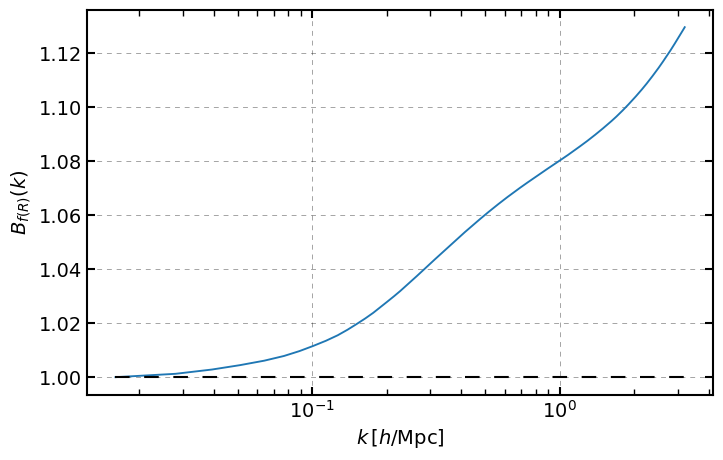

In [6]:
plt.semilogx(k_vals, Bk)
plt.xlabel(r'$k \, [h/{\rm Mpc}]$')
plt.ylabel(r'$B_{ f(R)}(k)$')
plt.hlines(1,k_vals.min(),k_vals.max(), 'k','--', lw=1.5);

The emulator can produce predictions for arbitrary values of the wavenumber k in the interpolation range. This is how to do it.

In [7]:

# Get boost for custom k values
k_custom = np.logspace(-1.5, 0.5, 10)
Bk_custom = model.predict(fR0,z,cosmo_params, k_out=k_custom)

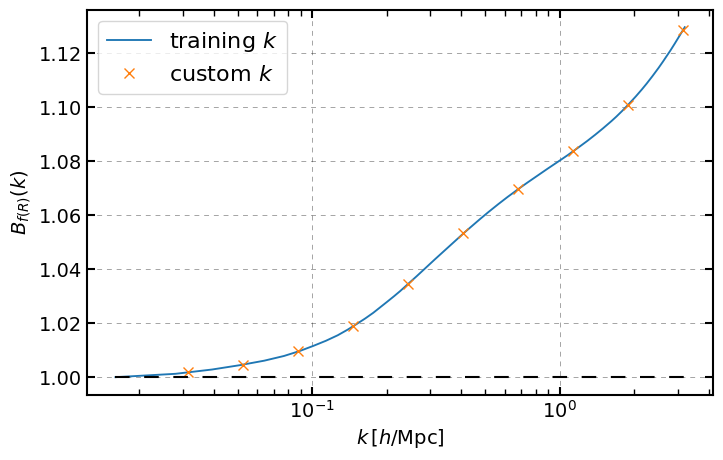

In [8]:
plt.semilogx(k_vals, Bk, label='training $k$')
plt.semilogx(k_custom, Bk_custom, 'x', ms=7, label='custom $k$')
plt.xlabel(r'$k \, [h/{\rm Mpc}]$')
plt.ylabel(r'$B_{f(R)}(k)$')
plt.hlines(1,k_vals.min(),k_vals.max(), 'k','--', lw=1.5);
plt.legend();

The emulator can also extrapolate outside the range for wavenumber k. You can do that using the "ext" argument. Be careful that for $k>k_{\rm max}$ the results are unreliable. For $k<k_{\rm min}$ instead, the extrapolated values should be in good agreement with the linear predictions. 

In [9]:

# Get boost for custom k values
k_ext = np.logspace(-2, 1, 30)
Bk_ext = model.predict(fR0,z,cosmo_params, k_out=k_ext, ext=0)

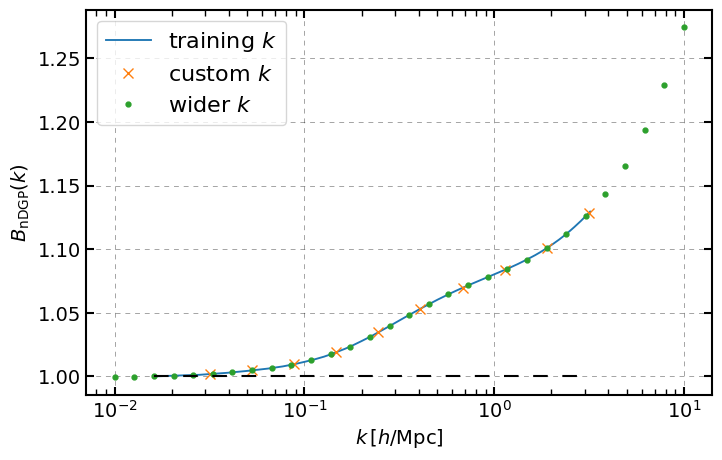

In [10]:
plt.semilogx(k_vals, Bk, label='training $k$')
plt.semilogx(k_custom, Bk_custom, 'x', ms=7, label='custom $k$')
plt.semilogx(k_ext, Bk_ext, '.', ms=7, label='wider $k$')
plt.xlabel(r'$k \, [h/{\rm Mpc}]$')
plt.ylabel(r'$B_{\rm nDGP}(k)$')
plt.hlines(1,k_vals.min(),k_vals.max(), 'k','--', lw=1.5);
plt.legend();